In [1]:
import pandas as pd
import numpy as np


In [2]:
# Read the CSV file
file_path = '3-url_audio_features.csv'
df = pd.read_csv(file_path)

# Check the data
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())


Shape: (661, 142)
Columns: ['url', 'title', 'label', 'audio_1', 'audio_2', 'audio_3', 'audio_4', 'audio_5', 'audio_6', 'audio_7', 'audio_8', 'audio_9', 'audio_10', 'audio_11', 'audio_12', 'audio_13', 'audio_14', 'audio_15', 'audio_16', 'audio_17', 'audio_18', 'audio_19', 'audio_20', 'audio_21', 'audio_22', 'audio_23', 'audio_24', 'audio_25', 'audio_26', 'audio_27', 'audio_28', 'audio_29', 'audio_30', 'audio_31', 'audio_32', 'audio_33', 'audio_34', 'audio_35', 'audio_36', 'audio_37', 'audio_38', 'audio_39', 'audio_40', 'audio_41', 'audio_42', 'audio_43', 'audio_44', 'audio_45', 'audio_46', 'audio_47', 'audio_48', 'audio_49', 'audio_50', 'audio_51', 'audio_52', 'audio_53', 'audio_54', 'audio_55', 'audio_56', 'audio_57', 'audio_58', 'audio_59', 'audio_60', 'audio_61', 'audio_62', 'audio_63', 'audio_64', 'audio_65', 'audio_66', 'audio_67', 'audio_68', 'audio_69', 'audio_70', 'audio_71', 'audio_72', 'audio_73', 'audio_74', 'audio_75', 'audio_76', 'audio_77', 'audio_78', 'audio_79', 'audio_8

In [3]:
df

,url,title,label,audio_1,audio_2,audio_3,audio_4,audio_5,audio_6,audio_7,...,audio_130,audio_131,audio_132,audio_133,audio_134,audio_135,audio_136,audio_137,audio_138,audio_139
0,https://youtube.com/shorts/qsEH_66Tz8o?si=HqLM...,THAT KNOCKOUT PUNCH💥📈,Violence,-39.564529,46.128994,-0.289782,8.153046,-0.129221,5.854639,96.435059,...,0.173027,0.120552,-0.062384,0.212305,-0.184402,0.152944,-0.001653,0.103880,-0.018139,0.088430
1,https://youtube.com/shorts/MQIEwDx9ctY?si=hlUr...,छावा अभी जिंदा है 😳🔥Vicky Kaushal #ytshorts #c...,Violence,-25.933229,54.995285,0.143285,7.430114,-0.032031,4.109614,93.310120,...,-0.000104,0.069427,0.002710,0.083181,0.013821,0.102171,0.001062,0.036908,-0.004815,0.032591
2,https://youtube.com/shorts/09sL1SlQ8hY?si=mzUD...,Father And Son 💀,Violence,-58.877933,84.686295,0.126546,11.139610,-0.106879,6.056201,100.418785,...,-0.069578,0.123761,0.037879,0.142721,-0.036099,0.124401,0.012986,0.061392,-0.021484,0.042064
3,https://youtube.com/shorts/VprRifC7J9U?si=0GF9...,Aura Farming by mahavatar Narsimha ✨🥶 #shorts ...,Violence,-105.580948,90.281265,0.225846,12.032714,-0.155462,6.701764,69.408554,...,-0.034034,0.142871,0.030207,0.186076,0.031254,0.129026,0.004231,0.056763,-0.007648,0.065229
4,https://youtube.com/shorts/okdcWqJLL8k?si=p5VW...,Rajasaab 🔥 x Daaha bgm☠️,Violence,-68.013580,81.310951,0.183316,9.715712,-0.084852,8.522561,82.178444,...,0.159053,0.092583,0.171360,0.121367,-0.043040,0.092497,0.035784,0.045823,-0.052093,0.043293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,https://youtube.com/shorts/UHVRuJLmpeg?si=cQq6...,Riddhima Sharma vs Chandrika Dixit: Vada Pav G...,Toxic,-207.677383,64.634109,0.077292,9.244516,-0.101217,5.461524,92.027344,...,0.001411,0.127949,0.000591,0.191747,-0.002066,0.178739,0.003570,0.070858,-0.011562,0.060945
657,https://youtube.com/shorts/fjDUJNfHpaM?si=1XFr...,Riddhima Sharma ने kanika Sharma को बताया ब्रा...,Toxic,-139.483246,70.314697,-0.003543,13.725224,-0.161889,9.501729,141.542984,...,0.104536,0.096084,-0.164294,0.151530,0.018247,0.135776,-0.041684,0.055061,-0.034639,0.049502
658,https://youtube.com/shorts/DQ-py4VFjDI?si=efP5...,Riddhima sharma on rock #hindu #mamtabanerjee ...,Toxic,-190.543396,84.982605,0.068828,11.161664,-0.127819,8.471173,78.055748,...,0.007656,0.116003,-0.010736,0.164767,0.017211,0.145972,-0.001065,0.059322,-0.004482,0.053704
659,https://youtube.com/shorts/2b_XYeNIOQ0?si=x-C-...,A Haryana Girl Came to CJP Protest Jantar Mant...,Toxic,-77.940315,41.308052,0.333542,7.775456,-0.449204,4.870203,108.101868,...,-0.010695,0.134201,0.024080,0.189207,0.005616,0.200190,-0.008174,0.072525,-0.006270,0.062977


In [4]:
class_labels = df["label"].unique().tolist()
print(class_labels)

['Violence', 'Hateful', 'Toxic', 'explicit', 'Normal', 'Explicit']


In [5]:
# Separate features, filename, and class ; first column is filename, last column is class
X = df.drop(columns=["url","title", "label"])
y = df["label"]

Lebel encoders

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 1, 3, 3, 3, 5, 5, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

Class to numeric mapping

In [7]:
# Visualize class to  numeric mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nClass to Numeric Mapping:")
for class_name, numeric in class_mapping.items():
    print(f"  {class_name} -> {numeric}")


Class to Numeric Mapping:
  Explicit -> 0
  Hateful -> 1
  Normal -> 2
  Toxic -> 3
  Violence -> 4
  explicit -> 5


# Step 3: Split into train and test data (80% train, 20% test)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=44,
    stratify=y_encoded  # Maintains class balance
)

In [9]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [10]:
# slect best model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="saga", random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128, 64, 32),max_iter=300,random_state=42)}

# Check if scaling is needed

In [11]:
needs_scaling = (X.mean().abs() > 0.01).any() or ((X.std() - 1).abs() > 0.01).any()

In [12]:
print(f"Needs Scaling: {needs_scaling}")
print(f"Max |Mean|: {X.mean().abs().max():.4f}")
print(f"Max |Std - 1|: {(X.std() - 1).abs().max():.4f}")

Needs Scaling: True
Max |Mean|: 4010.6873
Max |Std - 1|: 1041.6202


In [13]:
if needs_scaling:
    scaler = StandardScaler(with_mean=False)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
else:
    X_train_scaled = X_train
    X_test_scaled = X_test

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [15]:
for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

Show best model

In [16]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



Training Logistic Regression...
Accuracy: 0.3233


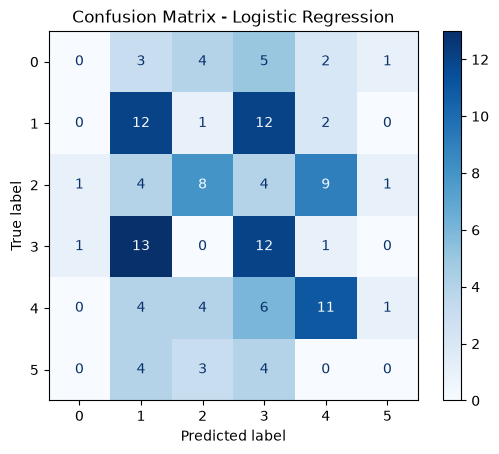


Training Naive Bayes...
Accuracy: 0.4511


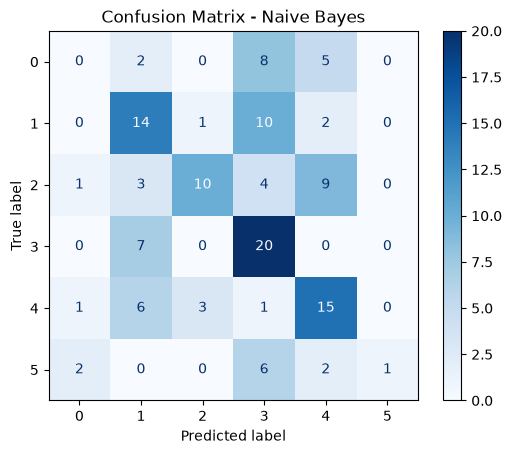


Training KNN...
Accuracy: 0.2180


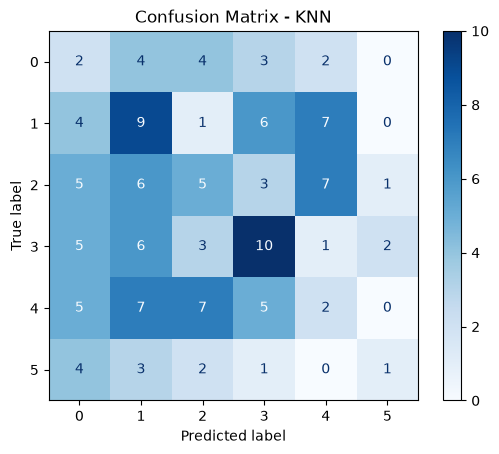


Training Decision Tree...
Accuracy: 0.3759


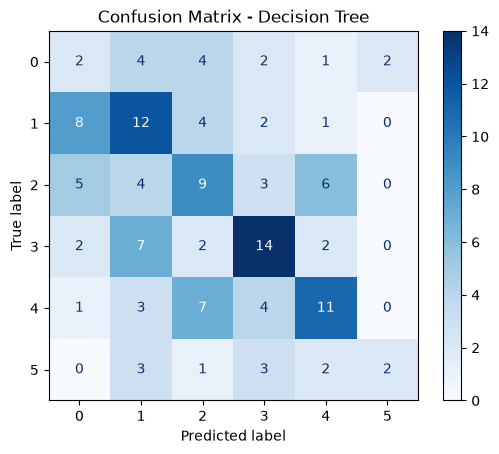


Training Random Forest...
Accuracy: 0.5188


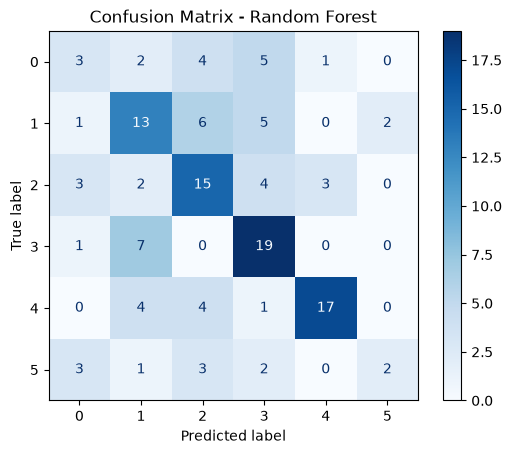


Training AdaBoost...
Accuracy: 0.4361


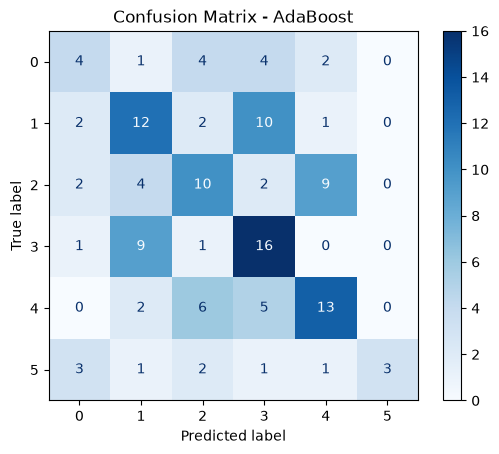


Training Gradient Boosting...
Accuracy: 0.5263


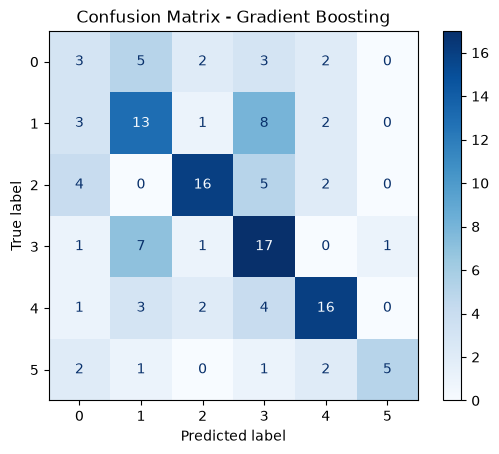


Training XGBoost...
Accuracy: 0.4812


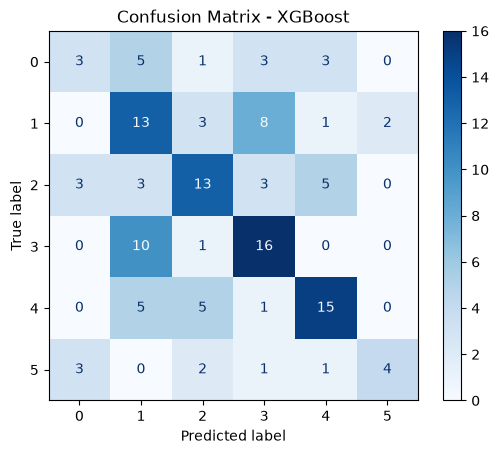


Training SVM...
Accuracy: 0.3459


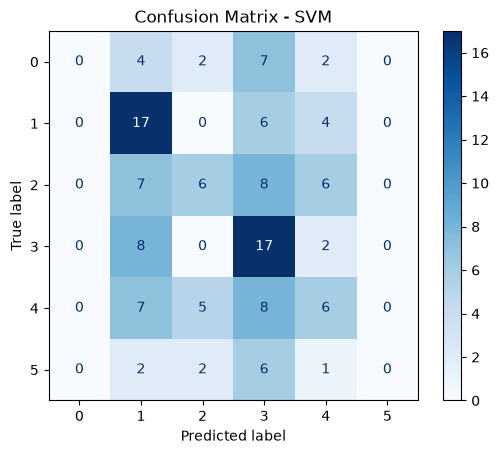


Training Neural Network...
Accuracy: 0.3684


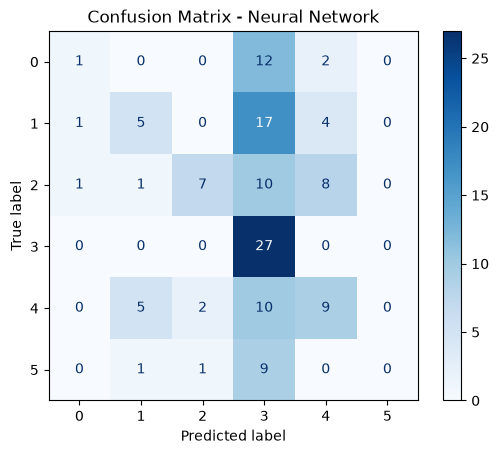

In [17]:
# Compare all models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"Accuracy: {accuracy:.4f}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [18]:
best_model= max(results, key=results.get)
print(f"\n{'='*50}")
print("BEST MODEL:")
best_model_name = max(results, key=results.get)
print(f"{best_model} with accuracy: {results[best_model]:.4f}")


BEST MODEL:
Gradient Boosting with accuracy: 0.5263


In [19]:
results_df1 = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df1)

                 Model  Accuracy
0  Logistic Regression  0.323308
1          Naive Bayes  0.451128
2                  KNN  0.218045
3        Decision Tree  0.375940
4        Random Forest  0.518797
5             AdaBoost  0.436090
6    Gradient Boosting  0.526316
7              XGBoost  0.481203
8                  SVM  0.345865
9       Neural Network  0.368421


K-fold stratefication

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        estimator = Pipeline([("scaler", StandardScaler()), ("model", model)])
    else:
        estimator = model

    scores = cross_validate(
        estimator,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1-Score": scores['test_f1'].mean()
    })
results_df2 = pd.DataFrame(results)
print(results_df2)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.465947   0.466781  0.465947  0.463827
1          Naive Bayes  0.447779   0.451746  0.447779  0.422137
2                  KNN  0.461340   0.482000  0.461340  0.435500
3        Decision Tree  0.422049   0.419374  0.422049  0.418501
4        Random Forest  0.508309   0.534646  0.508309  0.496940
5             AdaBoost  0.409927   0.407104  0.409927  0.398906
6    Gradient Boosting  0.512848   0.505788  0.512848  0.504420
7              XGBoost  0.547600   0.556424  0.547600  0.544334
8                  SVM  0.535493   0.559325  0.535493  0.524781
9       Neural Network  0.546072   0.545270  0.546072  0.541241
